<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%204/L4_CNN_Architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=1ic-vzTpJCE) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%204/NPTEL_Jul24_DL4CV_W04_P03.pdf)

In [ ]:
# Week 4, Lecture 4: CNN Architectures
from IPython.display import HTML, display

VIDEO_ID = "1ic-vzTpJCE"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# CNN Architectures for Image Classification: LeNet, AlexNet, VGG

Deep Learning for Computer Vision (NPTEL), Week 4, Lecture 4.3

This notebook traces the early history of convolutional network architectures and the
ideas that made them work, using small PyTorch experiments you can run and tweak.

**What you will learn**
- How a classifier turns raw scores (logits) into probabilities with softmax, and why
  cross-entropy is the loss of choice for classification.
- LeNet-5, the original CONV-POOL-CONV-POOL-FC design, built and trained on MNIST.
- AlexNet (2012) and ZFNet (2013), the models that started the deep learning boom on ImageNet.
- VGGNet (2014) and why a stack of small 3x3 convolutions beats one large kernel.
- Where the parameters and the compute actually live inside these networks.

**Prerequisites**: basic Python, numpy, and intro neural networks (a convolution is a small
filter slid over an image).

**How to use this notebook**
- Run the cells top to bottom.
- On Google Colab the interactive sliders work automatically; just drag them.
- Everything is tiny and fast. Only LeNet is trained, on a small MNIST subset for a few epochs.

In [1]:
# Setup: imports, reproducibility, and device selection
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Device: this line works unchanged on both CPU and GPU Colab runtimes
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('torch version:', torch.__version__)

# Helper to build a torchvision model with RANDOM weights (no download).
# It tries the new API (weights=None) and falls back to the old one (pretrained=False).
import torchvision.models as tvm
def build_random_model(name):
    ctor = getattr(tvm, name)
    try:
        return ctor(weights=None)      # newer torchvision
    except TypeError:
        return ctor(pretrained=False)  # older torchvision

print('Setup complete.')

Using device: cpu
torch version: 2.8.0


Setup complete.


## 1. A short history of CNN architectures

- **Neocognitron (1980, Fukushima)**: an early hierarchical model of simple and complex
  cells; the conceptual ancestor of the CNN.
- **LeNet-5 (1989 to 1998, LeCun et al.)**: the first practical CNN, used to read
  handwritten digits and bank cheques.
  - Convolution filters were 5x5, applied at stride 1.
  - Subsampling (pooling) layers were 2x2, applied at stride 2.
  - Overall structure: [CONV-POOL-CONV-POOL-FC-FC].
- **ImageNet / ILSVRC (since 2010)**: a large labelled image database organised by the
  WordNet hierarchy, with hundreds of images per node. The ImageNet Large Scale Visual
  Recognition Challenge became the standard benchmark for image classification.
  - Scored by **Top-1 error** (is the single top prediction correct) and **Top-5 error**
    (is the true class among the top 5 predictions).

The winners of this challenge tell the story of this lecture: LeNet led to AlexNet (2012),
then ZFNet (2013), then VGG (2014).

## 2. From logits to a loss: softmax and cross-entropy

A classifier outputs one raw score per class, called a **logit**. Two steps turn these
scores into a training signal.

**Softmax** converts logits $z$ into probabilities that are positive and sum to 1:

$$a_j = \frac{e^{z_j}}{\sum_k e^{z_k}}$$

**Cross-entropy** compares the predicted probabilities $\hat y$ with the one-hot true label $y$:

$$L = -\sum_{i=1}^{C} y_i \log \hat y_i$$

(the slide writes an averaging constant $\frac{1}{C}$ in front; PyTorch sums over classes
for each sample and averages over the batch). In the binary case this is
$L = -\,y\log\hat y - (1-y)\log(1-\hat y)$.

**Why not mean squared error?** With a sigmoid or softmax output, the gradient of
cross-entropy with respect to a last-layer weight simplifies to a clean form whose last
term is

$$x_j\,(\hat y - y)$$

This resembles the last term of the MSE gradient but without the extra $\sigma'(z)$ factor
that can shrink toward zero and stall learning. So cross-entropy trains faster and is the
standard choice for classification.

In [2]:
# Peel the onion: implement softmax and cross-entropy by hand,
# then check they agree with PyTorch's built-ins.

def softmax_rows(z):
    # z: (N, C) logits. Subtract the per-row max for numerical stability.
    z = z - z.max(dim=1, keepdim=True).values
    e = torch.exp(z)
    return e / e.sum(dim=1, keepdim=True)

def cross_entropy_scratch(logits, targets):
    # logits: (N, C), targets: (N,) class indices
    probs = softmax_rows(logits)
    n = logits.shape[0]
    true_class_prob = probs[torch.arange(n), targets]   # p of the correct class per row
    return (-torch.log(true_class_prob)).mean()          # average over the batch

# A random test batch
torch.manual_seed(1)
logits  = torch.randn(5, 4)
targets = torch.randint(0, 4, (5,))

# 1) our softmax matches F.softmax
same_softmax = torch.allclose(softmax_rows(logits), F.softmax(logits, dim=1), atol=1e-6)
print('softmax matches F.softmax        :', same_softmax)

# 2) our cross-entropy matches nn.CrossEntropyLoss
ce_scratch = cross_entropy_scratch(logits, targets)
ce_torch   = nn.CrossEntropyLoss()(logits, targets)
print('scratch CE = %.6f   nn.CrossEntropyLoss = %.6f' % (ce_scratch.item(), ce_torch.item()))
print('cross-entropy matches nn version :', torch.allclose(ce_scratch, ce_torch, atol=1e-6))

softmax matches F.softmax        : True
scratch CE = 2.036878   nn.CrossEntropyLoss = 2.036878
cross-entropy matches nn version : True


In [3]:
# The "clean gradient": for softmax + cross-entropy, dL/dz = (y_hat - y).
z = torch.randn(1, 4, requires_grad=True)
t = torch.tensor([2])                      # true class is 2
loss = nn.CrossEntropyLoss()(z, t)
loss.backward()

analytic = softmax_rows(z.detach()) - F.one_hot(t, num_classes=4).float()
print('autograd gradient dL/dz :', z.grad.numpy().round(4))
print('(y_hat - y)             :', analytic.numpy().round(4))
print('they match              :', torch.allclose(z.grad, analytic, atol=1e-6))

autograd gradient dL/dz : [[ 0.17    0.254  -0.6593  0.2353]]
(y_hat - y)             : [[ 0.17    0.254  -0.6593  0.2353]]
they match              : True


In [4]:
# INTERACTIVE 1: drag the four logits and the temperature T, watch the softmax bars.
# Softmax with temperature:  a_j = exp(z_j / T) / sum_k exp(z_k / T).
# Small T -> peaky and confident;  large T -> flat and uncertain.
def show_softmax(z0=2.0, z1=1.0, z2=0.5, z3=-1.0, T=1.0):
    logits = torch.tensor([z0, z1, z2, z3])
    probs = softmax_rows((logits / T).unsqueeze(0)).squeeze(0)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
    classes = ['0', '1', '2', '3']
    ax1.bar(classes, logits.numpy(), color='steelblue')
    ax1.set_title('logits z'); ax1.set_ylabel('value'); ax1.set_ylim(-3.2, 3.2)
    ax2.bar(classes, probs.numpy(), color='indianred')
    ax2.set_ylim(0, 1); ax2.set_ylabel('probability')
    ax2.set_title('softmax(z / T),  T=%.2f,  sum=%.2f' % (T, probs.sum().item()))
    for i, p in enumerate(probs.numpy()):
        ax2.text(i, p + 0.02, '%.2f' % p, ha='center', fontsize=9)
    plt.tight_layout(); plt.show()

interact(show_softmax,
         z0=FloatSlider(min=-3, max=3, step=0.1, value=2.0),
         z1=FloatSlider(min=-3, max=3, step=0.1, value=1.0),
         z2=FloatSlider(min=-3, max=3, step=0.1, value=0.5),
         z3=FloatSlider(min=-3, max=3, step=0.1, value=-1.0),
         T=FloatSlider(min=0.2, max=5.0, step=0.1, value=1.0));

interactive(children=(FloatSlider(value=2.0, description='z0', max=3.0, min=-3.0), FloatSlider(value=1.0, desc…

## 3. Building LeNet-5

LeNet-5 is the template every later network builds on. Its pattern is
[CONV-POOL-CONV-POOL-FC-FC-FC]:

| Stage | Layer | Output size |
|-------|-------|-------------|
| input | grayscale image | 1 x 28 x 28 |
| C1 | Conv 5x5, 6 filters, pad 2 | 6 x 28 x 28 |
| S2 | MaxPool 2x2, stride 2 | 6 x 14 x 14 |
| C3 | Conv 5x5, 16 filters | 16 x 10 x 10 |
| S4 | MaxPool 2x2, stride 2 | 16 x 5 x 5 |
| C5 | FC | 120 |
| F6 | FC | 84 |
| out | FC | 10 |

MNIST images are 28x28 while the original LeNet expected 32x32. **Our choice**: add
`padding=2` to the first convolution so a 28x28 input stays 28x28 after C1, which
reproduces the original spatial sizes further down. We also use ReLU activations and max
pooling (the modern conventions that AlexNet later popularised) in place of the original
tanh and average subsampling.

Watch the two trends as the network gets deeper: the spatial size shrinks
(28 -> 14 -> 10 -> 5) while the number of channels grows (1 -> 6 -> 16).

In [5]:
class LeNet5(nn.Module):
    """LeNet-5 adapted for 28x28 MNIST (padding=2 on conv1 keeps the original sizes)."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)  # 1x28x28 -> 6x28x28
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)                # -> 6x14x14
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)           # -> 16x10x10
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)                # -> 16x5x5
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = LeNet5()
print(net)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [6]:
# Peel the onion: push one image through and print the shape after every stage.
# The spatial size shrinks while the channel count grows.
x = torch.randn(1, 1, 28, 28)
print('%-24s %s' % ('input', tuple(x.shape)))
x = net.conv1(x); x = F.relu(x); print('%-24s %s' % ('after conv1 (5x5, pad2)', tuple(x.shape)))
x = net.pool1(x);                print('%-24s %s' % ('after pool1 (2x2 s2)',    tuple(x.shape)))
x = net.conv2(x); x = F.relu(x); print('%-24s %s' % ('after conv2 (5x5)',       tuple(x.shape)))
x = net.pool2(x);                print('%-24s %s' % ('after pool2 (2x2 s2)',    tuple(x.shape)))
x = torch.flatten(x, 1);         print('%-24s %s' % ('after flatten',           tuple(x.shape)))
x = net.fc1(x);                  print('%-24s %s' % ('after fc1',               tuple(x.shape)))
x = net.fc2(x);                  print('%-24s %s' % ('after fc2',               tuple(x.shape)))
x = net.fc3(x);                  print('%-24s %s' % ('after fc3 (logits)',      tuple(x.shape)))

input                    (1, 1, 28, 28)
after conv1 (5x5, pad2)  (1, 6, 28, 28)
after pool1 (2x2 s2)     (1, 6, 14, 14)
after conv2 (5x5)        (1, 16, 10, 10)
after pool2 (2x2 s2)     (1, 16, 5, 5)
after flatten            (1, 400)
after fc1                (1, 120)
after fc2                (1, 84)
after fc3 (logits)       (1, 10)


In [7]:
# Per-layer parameter count for LeNet-5.
print('%-12s %-22s %12s' % ('parameter', 'shape', 'count'))
print('-' * 48)
total = 0
for name, p in net.named_parameters():
    total += p.numel()
    print('%-12s %-22s %12d' % (name, str(tuple(p.shape)), p.numel()))
print('-' * 48)
print('%-35s %12d' % ('TOTAL trainable parameters', total))

parameter    shape                         count
------------------------------------------------
conv1.weight (6, 1, 5, 5)                    150
conv1.bias   (6,)                              6
conv2.weight (16, 6, 5, 5)                  2400
conv2.bias   (16,)                            16
fc1.weight   (120, 400)                    48000
fc1.bias     (120,)                          120
fc2.weight   (84, 120)                     10080
fc2.bias     (84,)                            84
fc3.weight   (10, 84)                        840
fc3.bias     (10,)                            10
------------------------------------------------
TOTAL trainable parameters                 61706


## 4. Training LeNet-5 on MNIST

We train on a small subset so the whole thing runs in well under a minute on a CPU:
- 6000 training images and 1000 test images (out of the full 60000 and 10000).
- 3 epochs, batch size 128.
- Adam optimiser and cross-entropy loss.

This is enough to reach roughly 95% test accuracy and to learn recognisable filters. The
original networks were trained with SGD; here we use Adam only to converge quickly on the
tiny subset.

In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# root='./data' and download=True so this cell works unchanged on Colab.
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),   # MNIST mean and std
])
train_full = datasets.MNIST(root='./data', train=True,  download=True, transform=tfm)
test_full  = datasets.MNIST(root='./data', train=False, download=True, transform=tfm)

# Small subsets for speed
train_set = Subset(train_full, range(6000))
test_set  = Subset(test_full,  range(1000))

# num_workers=0 keeps this headless-safe and Colab-safe
train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=0)
print('train images:', len(train_set), '| test images:', len(test_set))
print('train batches:', len(train_loader), '| test batches:', len(test_loader))

train images: 6000 | test images: 1000
train batches: 47 | test batches: 4


In [9]:
import time

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return correct / total

torch.manual_seed(0)
model = LeNet5().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()

loss_history, acc_history = [], []
EPOCHS = 3
t0 = time.time()
for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    acc = evaluate(model, test_loader)
    acc_history.append(acc)
    print('epoch %d/%d   last-batch loss %.3f   test accuracy %.3f'
          % (epoch + 1, EPOCHS, loss_history[-1], acc))
print('trained in %.1f s on %s' % (time.time() - t0, device))

epoch 1/3   last-batch loss 0.368   test accuracy 0.853


epoch 2/3   last-batch loss 0.178   test accuracy 0.912


epoch 3/3   last-batch loss 0.150   test accuracy 0.948
trained in 2.9 s on cpu


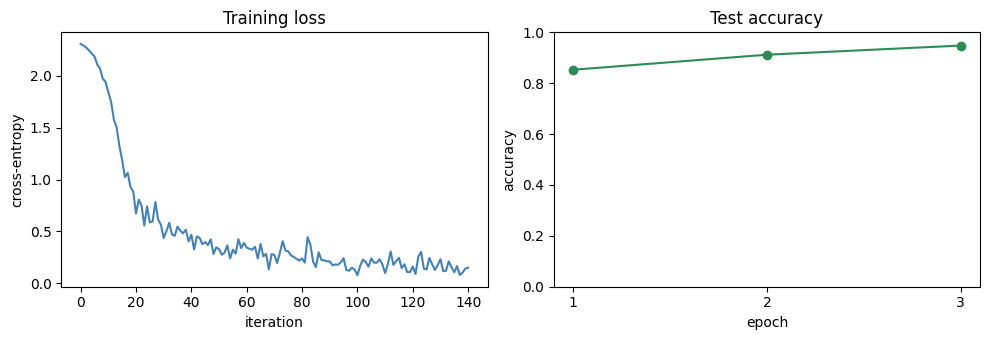

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(loss_history, color='steelblue')
ax1.set_title('Training loss'); ax1.set_xlabel('iteration'); ax1.set_ylabel('cross-entropy')
ax2.plot(range(1, EPOCHS + 1), acc_history, 'o-', color='seagreen')
ax2.set_title('Test accuracy'); ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy')
ax2.set_ylim(0, 1); ax2.set_xticks(range(1, EPOCHS + 1))
plt.tight_layout(); plt.show()

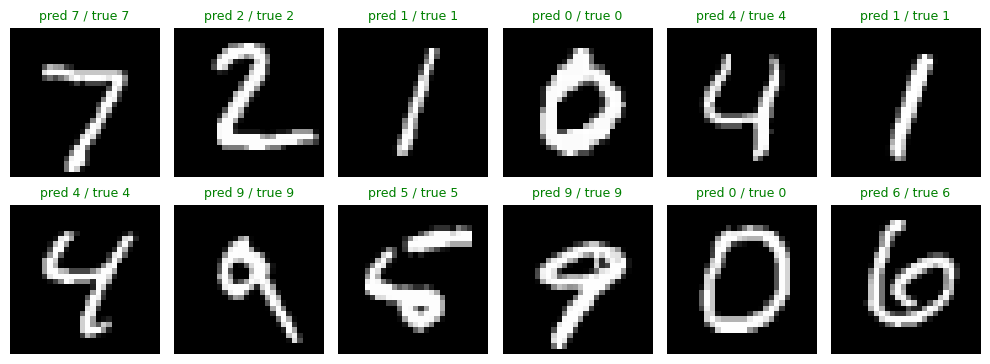

In [11]:
# Predictions on a handful of test images. Green title = correct, red = wrong.
model.eval()
xb, yb = next(iter(test_loader))
with torch.no_grad():
    preds = model(xb.to(device)).argmax(dim=1).cpu()

mean, std = 0.1307, 0.3081
fig, axes = plt.subplots(2, 6, figsize=(10, 3.8))
for i, ax in enumerate(axes.flat):
    img = xb[i, 0] * std + mean          # un-normalise just for display
    ax.imshow(img, cmap='gray')
    ok = preds[i].item() == yb[i].item()
    ax.set_title('pred %d / true %d' % (preds[i].item(), yb[i].item()),
                 color='green' if ok else 'red', fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()

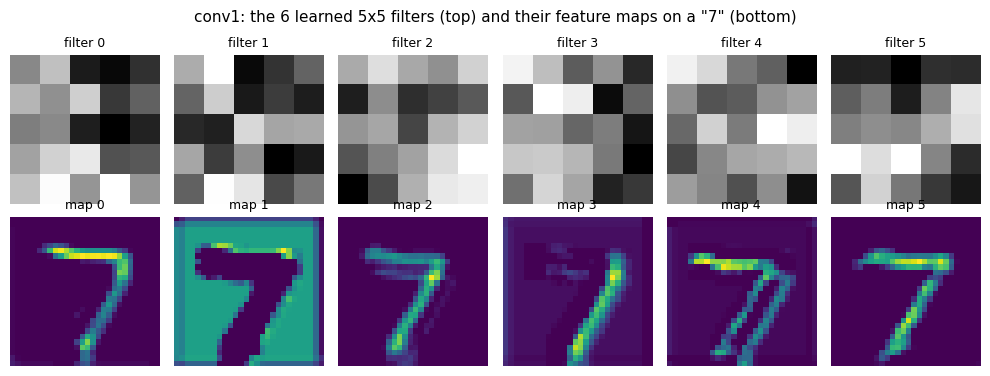

In [12]:
# What did conv1 learn? Show its 6 filters (each 5x5) and the 6 feature maps for one digit.
w = model.conv1.weight.detach().cpu()               # shape (6, 1, 5, 5)
img, label = test_set[0]
with torch.no_grad():
    fmaps = F.relu(model.conv1(img.unsqueeze(0).to(device))).cpu()[0]   # shape (6, 28, 28)

fig, axes = plt.subplots(2, 6, figsize=(10, 3.8))
for i in range(6):
    axes[0, i].imshow(w[i, 0], cmap='gray');    axes[0, i].axis('off')
    axes[0, i].set_title('filter %d' % i, fontsize=9)
    axes[1, i].imshow(fmaps[i], cmap='viridis'); axes[1, i].axis('off')
    axes[1, i].set_title('map %d' % i, fontsize=9)
fig.suptitle('conv1: the 6 learned 5x5 filters (top) and their feature maps on a "%d" (bottom)'
             % label, fontsize=11)
plt.tight_layout(); plt.show()

## 5. The ImageNet era: AlexNet (2012) and ZFNet (2013)

**AlexNet** won ILSVRC-2012 and reignited interest in deep learning. Its design is
"LeNet but deeper", with convolution layers stacked on top of each other.
- **8 learned layers**: 5 convolutional plus 3 fully connected.
- **ReLU** non-linearity applied to the output of every layer (much faster to train than tanh).
- **Local Response Normalization** after the first and second convolution layers.
- **Max pooling** after the first, second, and fifth convolution layers.
- Trained on 1.2M ImageNet images using SGD with regularization, on two NVIDIA GTX 580 3GB
  GPUs for about a week.
- Where the work is: convolution layers hold about 90 to 95% of the compute but only about
  5% of the parameters, while the fully connected layers hold about 95% of the parameters.
  We verify this in section 7.

**ZFNet** (2013 winner) is AlexNet with two tweaks found by visualising what the network learned:
- CONV1 changed from 11x11 stride 4 to 7x7 stride 2 (keep finer detail).
- CONV3, 4, 5 filter counts changed from 384, 384, 256 to 512, 1024, 512.
- Result: ImageNet Top-5 error improved from 16.4% to 11.7%.

## 6. VGGNet (2014): depth through 3x3 convolutions

VGG was the ILSVRC-2014 runner-up, and its key contribution is a clear message:
**depth is what matters**. It reaches that depth with a strikingly **homogeneous** design
used from beginning to end:
- **3x3 CONV, stride 1, pad 1** (the spatial size is preserved).
- **2x2 MAX POOL, stride 2** (the spatial size is halved).

**The central trick: small stacked filters replace large ones.**
- Two stacked 3x3 convs see the same 5x5 region as one 5x5 conv.
- Three stacked 3x3 convs see the same 7x7 region as one 7x7 conv.
- In general, $n$ stacked 3x3 convs have a receptive field of size $1 + 2n$.

Why prefer the stack? For the same receptive field it uses **fewer parameters** and adds
**more non-linearities** (one ReLU per conv). With $C$ input and output channels, three
3x3 convs cost $3\times(3^2 C^2) = 27C^2$ weights versus $7^2 C^2 = 49C^2$ for one 7x7 conv.

In [13]:
# INTERACTIVE 2: stack n convolutions of size 3x3 (stride 1).
# Left: the receptive field grows to (1 + 2n). Right: parameters vs one equivalent big kernel.
import matplotlib.patches as patches

def show_receptive_field(n_layers=2, C=64):
    rf = 1 + 2 * n_layers                        # receptive field size of the stack
    stacked_params = n_layers * (3 * 3) * C * C   # n convs of 3x3 mapping C -> C channels
    single_params  = (rf * rf) * C * C            # one conv of size rf x rf, C -> C channels

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))

    # Left: nested receptive fields, one square added per stacked layer
    lim = rf // 2 + 1
    ax1.set_xlim(-lim, lim); ax1.set_ylim(-lim, lim); ax1.set_aspect('equal')
    ax1.set_xticks(range(-lim, lim + 1)); ax1.set_yticks(range(-lim, lim + 1))
    ax1.grid(True, alpha=0.3)
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, n_layers))
    for k in range(1, n_layers + 1):
        r = k                                     # side length after k layers is 2k+1
        rect = patches.Rectangle((-r - 0.5, -r - 0.5), 2 * r + 1, 2 * r + 1,
                                 fill=False, edgecolor=colors[k - 1], linewidth=2,
                                 label='after conv %d: %dx%d' % (k, 2 * r + 1, 2 * r + 1))
        ax1.add_patch(rect)
    ax1.plot(0, 0, 's', color='crimson', markersize=6)
    ax1.set_title('Receptive field of %d stacked 3x3 convs = %dx%d' % (n_layers, rf, rf))
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), fontsize=8)

    # Right: parameter comparison
    labels = ['%d x (3x3)' % n_layers, 'one %dx%d' % (rf, rf)]
    values = [stacked_params, single_params]
    bars = ax2.bar(labels, values, color=['seagreen', 'indianred'])
    ax2.set_title('Parameters at C=%d channels' % C)
    ax2.set_ylabel('weights')
    for b, v in zip(bars, values):
        ax2.text(b.get_x() + b.get_width() / 2, v, '{:,}'.format(v),
                 ha='center', va='bottom', fontsize=9)
    ax2.margins(y=0.15)
    plt.tight_layout(); plt.show()

interact(show_receptive_field,
         n_layers=IntSlider(min=1, max=5, step=1, value=2),
         C=IntSlider(min=8, max=256, step=8, value=64));

interactive(children=(IntSlider(value=2, description='n_layers', max=5, min=1), IntSlider(value=64, descriptio…

## 7. Where do the parameters live?

Let us instantiate three networks with random weights (no downloads, this is instant) and
count their parameters:
- our **LeNet-5**,
- **AlexNet**,
- **VGG16**.

We split each network's parameters into convolution layers versus fully connected (linear)
layers. This reproduces two claims from the slides:
1. Fully connected layers dominate the parameter count (roughly 95%).
2. For VGG, most of those parameters sit in the **first** fully connected layer.

In [14]:
lenet   = LeNet5()
alexnet = build_random_model('alexnet')   # random weights, downloads nothing
vgg16   = build_random_model('vgg16')     # random weights, downloads nothing

def conv_fc_split(model):
    conv = fc = 0
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            conv += sum(p.numel() for p in m.parameters())
        elif isinstance(m, nn.Linear):
            fc += sum(p.numel() for p in m.parameters())
    return conv, fc

names  = ['LeNet-5', 'AlexNet', 'VGG16']
models = [lenet, alexnet, vgg16]
conv_counts, fc_counts = [], []

print('%-9s %14s %14s %14s %8s' % ('model', 'conv params', 'fc params', 'total', 'fc %'))
print('-' * 62)
for nm, mdl in zip(names, models):
    c, f = conv_fc_split(mdl)
    conv_counts.append(c); fc_counts.append(f)
    tot = c + f
    print('%-9s %14d %14d %14d %7.1f%%' % (nm, c, f, tot, 100 * f / tot))

# For VGG16, how much sits in the FIRST fully connected layer?
first_fc = next(m for m in vgg16.modules() if isinstance(m, nn.Linear))
first_fc_params = sum(p.numel() for p in first_fc.parameters())
vgg_total = conv_counts[2] + fc_counts[2]
print('-' * 62)
print('VGG16 first FC layer holds %d params = %.1f%% of all VGG16 parameters'
      % (first_fc_params, 100 * first_fc_params / vgg_total))

model        conv params      fc params          total     fc %
--------------------------------------------------------------
LeNet-5             2572          59134          61706    95.8%
AlexNet          2469696       58631144       61100840    96.0%
VGG16           14714688      123642856      138357544    89.4%
--------------------------------------------------------------
VGG16 first FC layer holds 102764544 params = 74.3% of all VGG16 parameters


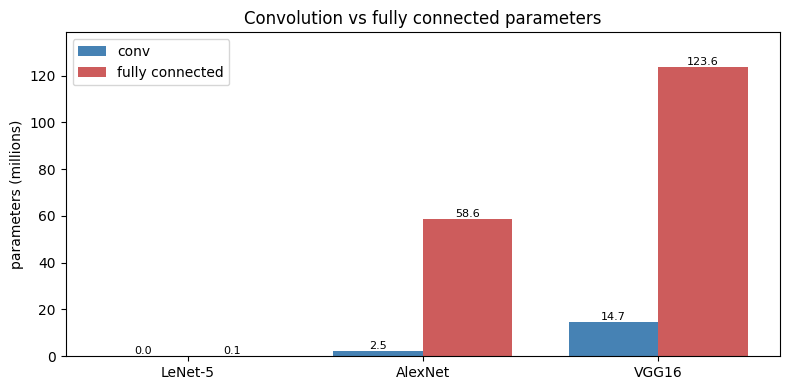

In [15]:
# Grouped bar chart: conv vs fully connected parameters (in millions).
x = np.arange(len(names))
width = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - width / 2, np.array(conv_counts) / 1e6, width, label='conv', color='steelblue')
b2 = ax.bar(x + width / 2, np.array(fc_counts) / 1e6, width, label='fully connected', color='indianred')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('parameters (millions)')
ax.set_title('Convolution vs fully connected parameters')
ax.legend()
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                '%.1f' % b.get_height(), ha='center', va='bottom', fontsize=8)
ax.margins(y=0.12)
plt.tight_layout(); plt.show()

In [16]:
# INTERACTIVE 3: pick an architecture, see its conv/linear layer table and parameter split.
def show_architecture(model_name='VGG16'):
    model = dict(zip(names, models))[model_name]
    rows = []
    for nm, m in model.named_modules():
        if isinstance(m, nn.Conv2d):
            p = sum(pp.numel() for pp in m.parameters())
            rows.append(('CONV', nm, '%d->%d, k=%d' % (m.in_channels, m.out_channels, m.kernel_size[0]), p))
        elif isinstance(m, nn.Linear):
            p = sum(pp.numel() for pp in m.parameters())
            rows.append(('FC', nm, '%d->%d' % (m.in_features, m.out_features), p))

    print('== %s: convolution and linear layers ==' % model_name)
    print('%-5s %-16s %-18s %12s' % ('type', 'name', 'shape', 'params'))
    print('-' * 54)
    for typ, nm, shape, p in rows:
        print('%-5s %-16s %-18s %12d' % (typ, nm[:16], shape, p))

    c, f = conv_fc_split(model)
    fig, ax = plt.subplots(figsize=(4.6, 4))
    ax.bar(['conv', 'fc'], [c / 1e6, f / 1e6], color=['steelblue', 'indianred'])
    ax.set_ylabel('parameters (millions)')
    ax.set_title('%s: conv %.2fM vs fc %.2fM' % (model_name, c / 1e6, f / 1e6))
    ax.margins(y=0.12)
    plt.tight_layout(); plt.show()

interact(show_architecture, model_name=Dropdown(options=names, value='VGG16'));

interactive(children=(Dropdown(description='model_name', index=2, options=('LeNet-5', 'AlexNet', 'VGG16'), val…

## 8. Design principles that carried forward

- **ReLU everywhere**: AlexNet replaced tanh and sigmoid with ReLU, which trains much
  faster and avoids saturation. Every network since uses it.
- **Depth wins**: going from LeNet (a few layers) to AlexNet (8) to VGG (16 to 19) steadily
  reduced error. More layers means more non-linearities and richer features.
- **Small 3x3 filters, stacked**: VGG showed that stacking small convs matches a large
  receptive field with fewer parameters and more non-linearity. This became the default
  building block.
- **Homogeneous, repeatable blocks**: VGG's uniform "3x3 conv, 2x2 pool" recipe is easy to
  reason about and to scale up.
- **Parameters live in the FC layers** (about 95%), and for VGG most of them are in the
  first FC layer. Later architectures shrink or remove these big FC layers.
- **Compute and memory live in the conv layers**: convolutions are about 90 to 95% of the
  compute, and the early conv layers (with large spatial maps) use most of the memory.
- **The progression**: Neocognitron -> LeNet -> AlexNet -> ZFNet -> VGG, each keeping what
  worked and pushing depth further.

## 9. Key takeaways

- A classifier maps logits to probabilities with **softmax** and is trained with
  **cross-entropy**, which gives the clean gradient $(\hat y - y)$ and beats MSE for
  classification.
- **LeNet-5** = [CONV-POOL-CONV-POOL-FC-FC-FC]; the spatial size shrinks while the channel
  count grows. It trains to about 95% on an MNIST subset in seconds.
- **AlexNet** = a deeper LeNet with ReLU, local response normalization, and max pooling; it
  won ImageNet 2012. **ZFNet** tuned its first conv and filter counts to cut Top-5 error
  from 16.4% to 11.7%.
- **VGG** = a deep, homogeneous stack of 3x3 convs; two 3x3 equal one 5x5 and three 3x3
  equal one 7x7, with fewer parameters ($27C^2$ versus $49C^2$).
- **Parameters** concentrate in the fully connected layers (about 95%); **compute and
  memory** concentrate in the convolution layers.

### Try it yourself
- In the softmax widget, set all four logits equal: every probability becomes 0.25. Then
  lower the temperature T toward 0.2 and watch one class dominate.
- Swap LeNet's optimiser for `torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)`
  and compare the loss curve.
- Increase the training subset to 12000 images or train for 5 epochs; how much does the
  test accuracy improve?
- In the receptive field widget, set n = 3 and read off $27C^2$ versus $49C^2$; then try
  larger C.
- In the architecture dropdown, confirm that AlexNet and VGG16 are about 95% fully
  connected parameters.

### Suggested reading
- Tutorial: "Illustrated: 10 CNN Architectures" (read the first three: LeNet, AlexNet, VGG).
- Optional papers: "ImageNet Classification with Deep Convolutional Neural Networks"
  (AlexNet, 2012); "Very Deep Convolutional Networks for Large-Scale Image Recognition"
  (VGG, 2014).